In [1]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt  
import tensorflow as tf



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
os.listdir("/content/drive/MyDrive")

['Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 'Resume.gdoc',
 'Untitled document.gdoc',
 'Copy of Practise 1 (2).xlsx',
 'Copy of Practise 1 (3).gsheet',
 'Copy of Practise 1 (2).gsheet',
 'Copy of MOCK_Updated.gsheet',
 'Copy of Practise 1 (1).xlsx',
 'Copy of Practise 1 (1).gsheet',
 'Copy of Practise 1.xlsx',
 'Copy of Practise 1.gsheet',
 'Iris.csv',
 'Colab Notebooks',
 'deep learning course',
 'diabetes_prediction_dataset.csv',
 'rnn project.ipynb',
 'qoute_dataset.csv',
 'lstm_model.h5',
 'Fake.csv',
 'True.csv']

In [4]:
import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/qoute_dataset.csv")
df.head()
df['quote'][0]

'“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”'

In [5]:
df.shape

(3038, 2)

In [6]:
quotes = df['quote']
print(quotes.head())

0    “The world as we have created it is a process ...
1    “It is our choices, Harry, that show what we t...
2    “There are only two ways to live your life. On...
3    “The person, be it gentleman or lady, who has ...
4    “Imperfection is beauty, madness is genius and...
Name: quote, dtype: object


In [7]:
quotes = quotes.str.lower()
quotes.head()

,quote
0,“the world as we have created it is a process ...
1,"“it is our choices, harry, that show what we t..."
2,“there are only two ways to live your life. on...
3,"“the person, be it gentleman or lady, who has ..."
4,"“imperfection is beauty, madness is genius and..."


In [8]:
quotes = df['quote'].str.lower().str.replace(r"[^\w\s]", "", regex=True)

In [9]:
quotes.head()

,quote
0,the world as we have created it is a process o...
1,it is our choices harry that show what we trul...
2,there are only two ways to live your life one ...
3,the person be it gentleman or lady who has not...
4,imperfection is beauty madness is genius and i...


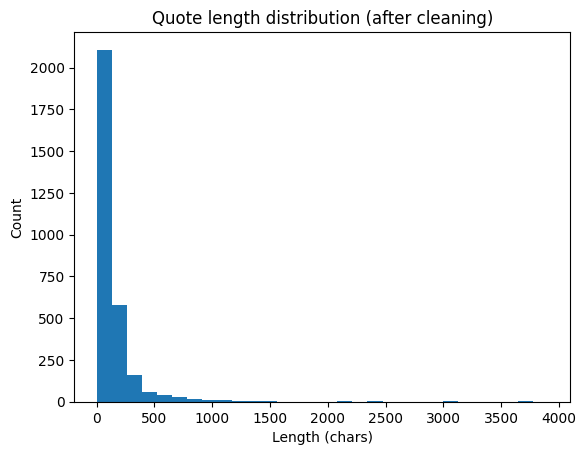

In [10]:
import matplotlib.pyplot as plt

lengths = df['quote'].str.len()
plt.hist(lengths, bins=30)
plt.title("Quote length distribution (after cleaning)")
plt.xlabel("Length (chars)")
plt.ylabel("Count")
plt.show()

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(quotes)



In [12]:
word_index = tokenizer.word_index
print(f"word_index: {len(word_index)}")
list(word_index.items())[:10]

word_index: 8724


[('<OOV>', 1),
 ('the', 2),
 ('you', 3),
 ('to', 4),
 ('and', 5),
 ('a', 6),
 ('i', 7),
 ('is', 8),
 ('of', 9),
 ('that', 10)]

In [13]:


from tensorflow.keras.preprocessing.text import Tokenizer
sequences = tokenizer.texts_to_sequences(quotes)

In [14]:
quotes[0]

'the world as we have created it is a process of our thinking it cannot be changed without changing our thinking'

In [15]:
sequences[1]

[11, 8, 71, 864, 374, 10, 433, 22, 20, 465, 15, 297, 53, 55, 71, 2428]

In [16]:
for i in range(3):
    print(quotes[i])


the world as we have created it is a process of our thinking it cannot be changed without changing our thinking
it is our choices harry that show what we truly are far more than our abilities
there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle


In [17]:
for i in range(3):
    print(sequences[i])

[2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11, 147, 13, 805, 106, 742, 71, 286]
[11, 8, 71, 864, 374, 10, 433, 22, 20, 465, 15, 297, 53, 55, 71, 2428]
[43, 15, 54, 202, 707, 4, 82, 16, 36, 38, 8, 30, 313, 96, 8, 6, 1032, 2, 104, 8, 30, 313, 129, 8, 6, 1032]


In [18]:
X = []
y = []

for seq in sequences:
    for i in range (1, len(seq)):
        input_seq = seq[:i]
        output_seq = seq[i]
        X.append(input_seq)
        y.append(output_seq)

In [19]:
X


[[2],
 [2, 63],
 [2, 63, 30],
 [2, 63, 30, 20],
 [2, 63, 30, 20, 17],
 [2, 63, 30, 20, 17, 938],
 [2, 63, 30, 20, 17, 938, 11],
 [2, 63, 30, 20, 17, 938, 11, 8],
 [2, 63, 30, 20, 17, 938, 11, 8, 6],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11, 147],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11, 147, 13],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11, 147, 13, 805],
 [2, 63, 30, 20, 17, 938, 11, 8, 6, 1144, 9, 71, 286, 11, 147, 13, 805, 106],
 [2,
  63,
  30,
  20,
  17,
  938,
  11,
  8,
  6,
  1144,
  9,
  71,
  286,
  11,
  147,
  13,
  805,
  106,
  742],
 [2,
  63,
  30,
  20,
  17,
  938,
  11,
  8,
  6,
  1144,
  9,
  71,
  286,
  11,
  147,
  13,
  805,
  106,
  742,
  71],
 [11],
 [11, 8],
 [11

In [20]:
y

[63,
 30,
 20,
 17,
 938,
 11,
 8,
 6,
 1144,
 9,
 71,
 286,
 11,
 147,
 13,
 805,
 106,
 742,
 71,
 286,
 8,
 71,
 864,
 374,
 10,
 433,
 22,
 20,
 465,
 15,
 297,
 53,
 55,
 71,
 2428,
 15,
 54,
 202,
 707,
 4,
 82,
 16,
 36,
 38,
 8,
 30,
 313,
 96,
 8,
 6,
 1032,
 2,
 104,
 8,
 30,
 313,
 129,
 8,
 6,
 1032,
 117,
 13,
 11,
 2429,
 34,
 1033,
 32,
 83,
 14,
 598,
 12,
 6,
 75,
 1321,
 121,
 13,
 2430,
 330,
 8,
 298,
 743,
 8,
 635,
 5,
 40,
 145,
 4,
 13,
 678,
 1322,
 55,
 678,
 744,
 14,
 4,
 203,
 6,
 93,
 9,
 434,
 284,
 203,
 6,
 93,
 9,
 517,
 8,
 145,
 4,
 13,
 1323,
 18,
 22,
 3,
 15,
 55,
 4,
 13,
 178,
 18,
 22,
 3,
 15,
 14,
 17,
 14,
 1324,
 174,
 52,
 416,
 2432,
 707,
 10,
 314,
 274,
 184,
 8,
 41,
 6,
 806,
 1325,
 3,
 48,
 51,
 60,
 322,
 11,
 8,
 170,
 40,
 12,
 636,
 481,
 112,
 106,
 1034,
 8,
 41,
 3,
 51,
 275,
 36,
 8,
 22,
 3,
 66,
 11,
 49,
 185,
 22,
 86,
 133,
 4,
 745,
 59,
 127,
 40,
 6,
 1914,
 177,
 19,
 2,
 75,
 211,
 8,
 3,
 97,
 4,
 466,
 60,
 86,

In [21]:
len(X)

85212

In [22]:
len(y)

85212

In [23]:
max_len = max(len (x)  for x in X)
print(max_len)


745


In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_padded = pad_sequences(X, maxlen=max_len, padding='pre')
print(X_padded[0])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [25]:
X[0]

[2]

In [26]:

import numpy as np
y = np.array(y)

In [27]:
X_padded.shape

(85212, 745)

In [28]:
from tensorflow.keras.utils import to_categorical
y_hot_coded = to_categorical(y, num_classes=vocab_size)
print(y_hot_coded.shape)

(85212, 10000)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN, LSTM, Dense

In [30]:
embedding_dim = 50
rnn_units = 128

rnn_model = Sequential()
rnn_model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))
rnn_model.add(SimpleRNN(rnn_units))
rnn_model.add(Dense(vocab_size, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
rnn_model.compile( optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 100

batch_size = 128


: 

: 

In [33]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping


lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(rnn_units),
    Dropout(0.3),
    Dense(vocab_size, activation="softmax"),
])

lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


history_lstm = lstm_model.fit(
    X_padded,
    y_hot_coded,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
  
)

: 

: 

In [ ]:
# history_rnn = rnn_model.fit(X_padded, y_hot_coded, epochs=epochs, batch_size=batch_size, validation_split=0.1)

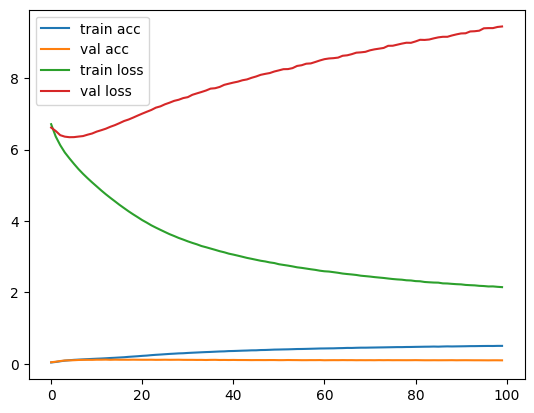

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history["accuracy"], label="train acc")
plt.plot(history_lstm.history["val_accuracy"], label="val acc")
plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.legend()
plt.show()

In [ ]:
print("Training Accuracy:", history_lstm.history['accuracy'][-1])

Training Accuracy: 0.5028947591781616


In [ ]:
print("Validation Accuracy:", history_lstm.history['val_accuracy'][-1])

Validation Accuracy: 0.09798169136047363


In [ ]:
print(y_hot_coded[:10])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

In [ ]:
lstm_model.save("/content/drive/MyDrive/lstm_model.h5")

In [ ]:
!ls /content

drive  rnn_model.h5  sample_data


In [ ]:
import numpy as np
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_word(text, model, tokenizer, index_to_word, max_len):

    text = re.sub(r"[^\w\s]", "", text.lower())

    sequence = tokenizer.texts_to_sequences([text])[0]

    seq = pad_sequences([sequence], maxlen=max_len, padding='pre')

    pred = model.predict(seq, verbose=0)

    pred_index = np.argmax(pred)

    return index_to_word.get(pred_index, "word_not_found")

In [ ]:
import pickle

# tokenizer save
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# max_len save
with open("max_len.pkl", "wb") as f:
    pickle.dump(max_len, f)

NameError: name 'model' is not defined